# WiFi CSI exploration — raw Widar3.0 `.dat` capture

Dataset
Widar3.0 (Zheng et al., MobiSys 2019) — a public WiFi sensing dataset for cross-domain gesture recognition, collected across 3 rooms (classroom, hall, office) with multiple users.
Two data types are provided:

CSI — raw .dat files from Intel 5300 NICs, named id-a-b-c-d-Rx.dat (user id, gesture type, torso location, face orientation, repetition, receiver id). Captured across 6 receivers, each with 3 antennas.

user id — which person performed the gesture
gesture type — which of the predefined gestures (Push&Pull, Sweep, Clap, etc.)
torso location — which fixed position in the room the person stood at
face orientation — which direction the person was facing
repetition — which repeat/trial number of that same gesture
receiver id — which of the 6 Rx devices recorded this file


BVP (Body-coordinate Velocity Profile) — precomputed .mat files, named id-a-b-c-d...mat. Each is a 20×20×T tensor: x-velocity axis (-2 to +2 m/s), y-velocity axis (-2 to +2 m/s), and T timestamps sampled at 10 Hz. This is the derived feature, already processed from raw CSI through Widar3.0's algorithmic defined pipeline.



Raw CSI → Doppler spectrogram, step by step (DFS/BVP-style pipeline). No training here, just understanding the signal.

## Stage 0 — load capture
`csiread` parses the Intel 5300 `.dat` file. Shape: `(packets, subcarriers, rx, tx)`. Only Tx0 has real data.

In [3]:
import csiread
import matplotlib.pyplot as plt
import numpy as np

# >>> set this to your .dat file <<<
filename = "/Users/umang.babu/Downloads/wifi/data/20181128/user6/user6-1-1-1-1-r3.dat"

csi = csiread.Intel(filename)
csi.read()

print(type(csi))
print(dir(csi))
print(csi.csi)
print(csi.csi.shape)

packet = csi.csi[0]
print(packet.shape)

<class 'csiread.core.Intel'>connector_log=0x1
1455 0xbb packets parsed

['Nrx', 'Ntx', '_Intel__report', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__pyx_vtable__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'addr_bssid', 'addr_des', 'addr_src', 'agc', 'apply_sm', 'bfee_count', 'count', 'csi', 'display', 'dur', 'fc', 'file', 'get_scaled_csi', 'get_scaled_csi_sm', 'get_total_rss', 'noise', 'payload', 'perm', 'pmsg', 'rate', 'read', 'readstp', 'rssi_a', 'rssi_b', 'rssi_c', 'seek', 'seq', 'stp', 'timestamp_low']
[[[[ 16.+16.j   0. +0.j]
   [ -6. -8.j   0. +0.j]
   [ 31. +2.j   0. +0.j]]

  [[ 24. -7.j   0. +0.j]
   [-11. +0.j   0. +0.j]
   [ 20.-29.j   0. +0.j]]

  [[  9.-26.j   0. +0.j]


## Stage 1 — drop unused Tx
Tx1 is all zeros. Keep `H = csi[:,:,:,0]` → `(packets, subcarriers, rx)`.

In [4]:
# keep Tx0 only
H = csi.csi[:, :, :, 0]
print(H.shape)

(1455, 30, 3)


In [5]:
n_packet, n_sc, n_rx = H.shape

print(f"Packets      : {n_packet}")
print(f"Subcarriers  : {n_sc}")
print(f"RX antennas  : {n_rx}")


Packets      : 1455
Subcarriers  : 30
RX antennas  : 3


## Stage 2 — amplitude & phase
`H = |H| * exp(j·phase)`. Raw phase is noisy (SFO/PLL artifacts), not usable directly — fixed later via conjugate multiplication.

In [6]:
import numpy as np
amp = np.abs(H)
phase = np.angle(H)

print(amp.shape)
print(phase.shape)

(1455, 30, 3)
(1455, 30, 3)


In [7]:
packet = 0
rx = 0

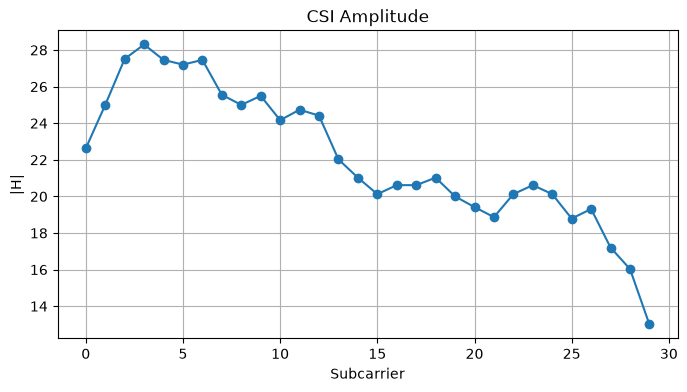

In [8]:
# amplitude vs subcarrier — smooth curve expected (frequency-selective fading)
plt.figure(figsize=(8, 4))
plt.plot(amp[packet, :, rx], 'o-')
plt.grid(True)

plt.xlabel("Subcarrier")
plt.ylabel("|H|")
plt.title("CSI Amplitude")
plt.show()

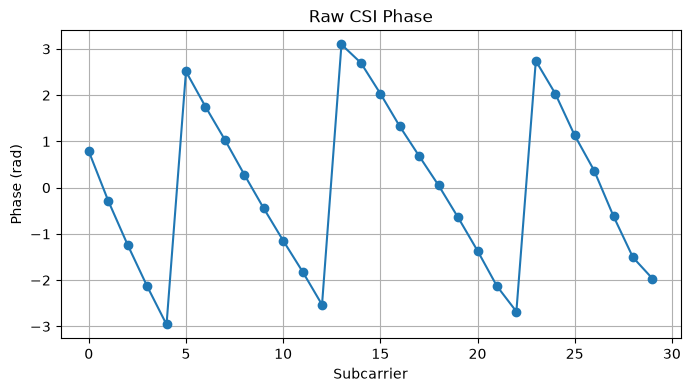

In [9]:
# raw phase — noisy/sawtooth, this is SFO artifact, not real channel info
plt.figure(figsize=(8, 4))
plt.plot(phase[packet, :, rx], 'o-')
plt.grid(True)

plt.xlabel("Subcarrier")
plt.ylabel("Phase (rad)")
plt.title("Raw CSI Phase")
plt.show()

In [10]:
subcarrier = 15
antenna = 0

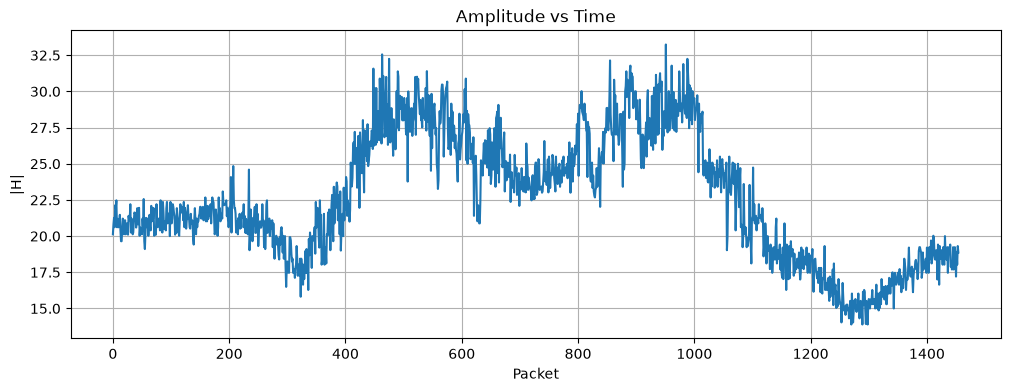

In [11]:
# amplitude over time, one subcarrier/antenna
plt.figure(figsize=(12, 4))
plt.plot(amp[:, subcarrier, antenna])

plt.xlabel("Packet")
plt.ylabel("|H|")
plt.title("Amplitude vs Time")
plt.grid(True)
plt.show()

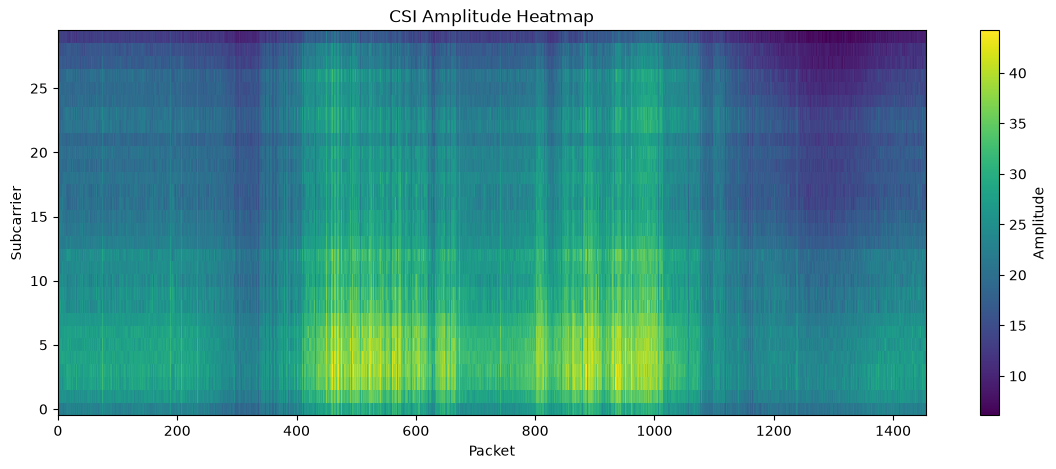

In [12]:
# full amplitude heatmap — motion shows up as vertical ripples across subcarriers
plt.figure(figsize=(14, 5))

plt.imshow(
    amp[:, :, 0].T,
    aspect='auto',
    origin='lower',
    interpolation='nearest'
)

plt.colorbar(label="Amplitude")
plt.xlabel("Packet")
plt.ylabel("Subcarrier")
plt.title("CSI Amplitude Heatmap")
plt.show()

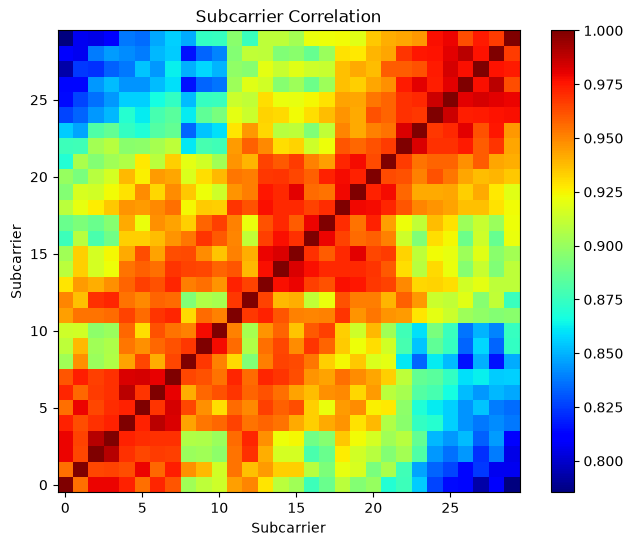

In [13]:
# subcarrier correlation — sanity check, nearby subcarriers should correlate
X = amp[:, :, antenna]

corr = np.corrcoef(X, rowvar=False)

plt.figure(figsize=(8, 6))
plt.imshow(corr, origin='lower', cmap='jet')
plt.colorbar()
plt.xlabel("Subcarrier")
plt.ylabel("Subcarrier")
plt.title("Subcarrier Correlation")
plt.show()

## Stage 2b — true subcarrier indices
The 30 reported groups map to real 802.11n subcarrier indices (-28..28), not 0..29. Needed for ToF/AoA-style work, not used below.

In [14]:
phase = np.angle(H)

In [15]:
packet = 0
rx = 0

phi = phase[packet, :, rx]

# true 802.11n subcarrier indices (20 MHz, Intel 5300 convention)
k = np.array([
    -28, -26, -24, -22, -20,
    -18, -16, -14, -12, -10,
     -8,  -6,  -4,  -2,  -1,
      1,   3,   5,   7,   9,
     11,  13,  15,  17,  19,
     21,  23,  25,  27,  28
])

In [16]:
print(dir(csi))

['Nrx', 'Ntx', '_Intel__report', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__pyx_vtable__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'addr_bssid', 'addr_des', 'addr_src', 'agc', 'apply_sm', 'bfee_count', 'count', 'csi', 'display', 'dur', 'fc', 'file', 'get_scaled_csi', 'get_scaled_csi_sm', 'get_total_rss', 'noise', 'payload', 'perm', 'pmsg', 'rate', 'read', 'readstp', 'rssi_a', 'rssi_b', 'rssi_c', 'seek', 'seq', 'stp', 'timestamp_low']


## Stage 3 — flatten + pick reference antenna
Flatten to `(packets, 90)` = 3 antennas × 30 subcarriers. Reference antenna = highest mean/std (strongest, most stable).

In [17]:
# (packet, subcarrier, rx) -> (packet, rx, subcarrier) -> flatten
H_widar = np.transpose(H, (0, 2, 1))
csi_streams = H_widar.reshape(H.shape[0], -1)

print(csi_streams.shape)  # (packets, 90)

(1455, 90)


In [18]:
print(csi_streams[0])

[ 16.+16.j  24. -7.j   9.-26.j -15.-24.j -27. -5.j -22.+16.j  -5.+27.j
  13.+22.j  24. +7.j  23.-11.j  10.-22.j  -6.-24.j -20.-14.j -22. +1.j
 -19. +9.j  -9.+18.j   5.+20.j  16.+13.j  21. +1.j  16.-12.j   4.-19.j
 -10.-16.j -18. -9.j -19. +8.j  -9.+18.j   8.+17.j  18. +7.j  14.-10.j
   1.-16.j  -5.-12.j  -6. -8.j -11. +0.j  -6.+10.j   5.+12.j  12. +4.j
  10. -7.j   2.-11.j  -5. -8.j  -8. -2.j  -7. +3.j  -4. +5.j  -1. +6.j
   3. +5.j   5. +4.j   6. +2.j   6. -2.j   5. -6.j   1. -8.j  -4. -7.j
  -8. -3.j  -9. +3.j  -5. +8.j   1.+11.j   8.+10.j  14. +1.j  11.-12.j
  -2.-18.j -16. -7.j -15.+10.j  -7.+13.j  31. +2.j  20.-29.j -15.-35.j
 -37. -8.j -30.+22.j  -4.+34.j  20.+28.j  32. +8.j  28.-15.j  12.-30.j
 -10.-30.j -26.-17.j -32. +5.j -21.+21.j -11.+27.j  10.+26.j  24.+15.j
  27. -3.j  19.-20.j   2.-25.j -16.-21.j -24. -7.j -26.+10.j -12.+26.j
  10.+28.j  28.+11.j  27.-14.j   3.-27.j -20.-18.j -20. -5.j]


In [19]:
# sanity check: reshape didn't scramble anything
print(H[0, :, 0][:10])

[ 16.+16.j  24. -7.j   9.-26.j -15.-24.j -27. -5.j -22.+16.j  -5.+27.j
  13.+22.j  24. +7.j  23.-11.j]


In [20]:
print(H[0, :, 1][:10])

[ -6. -8.j -11. +0.j  -6.+10.j   5.+12.j  12. +4.j  10. -7.j   2.-11.j
  -5. -8.j  -8. -2.j  -7. +3.j]


In [21]:
print(H[0, :, 2][:10])

[ 31. +2.j  20.-29.j -15.-35.j -37. -8.j -30.+22.j  -4.+34.j  20.+28.j
  32. +8.j  28.-15.j  12.-30.j]


In [22]:
csi_streams.shape

(1455, 90)

In [23]:
# per-stream stability score: mean/std (high = strong & steady)
amp = np.abs(csi_streams)

mean_amp = np.mean(amp, axis=0)
std_amp = np.std(amp, axis=0)

score = mean_amp / (std_amp + 1e-12)

In [24]:
score = score.reshape(3, 30)

In [25]:
antenna_score = score.mean(axis=1)
print(antenna_score)

[ 5.31525491  2.56807818 16.66212161]


In [26]:
reference = np.argmax(antenna_score)
print(reference)

2


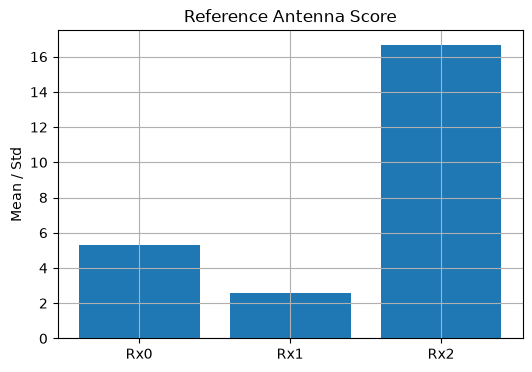

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(["Rx0", "Rx1", "Rx2"], antenna_score)
plt.ylabel("Mean / Std")
plt.title("Reference Antenna Score")
plt.grid(True)
plt.show()

In [28]:
print("Per-antenna score:", antenna_score)
print("Reference antenna:", reference)

Per-antenna score: [ 5.31525491  2.56807818 16.66212161]
Reference antenna: 2


## Stage 4 — conjugate multiplication
All antennas share one noisy oscillator. Dividing by a reference antenna cancels that common phase noise, keeping the real motion-sensitive phase difference.

In [29]:
# overrides Stage 3's pick for this experiment
reference = 2

In [30]:
# slice out the reference antenna's 30 columns, keep the rest separately
start = reference * 30
end = start + 30

reference_csi = csi_streams[:, start:end]

other_csi = np.concatenate(
    (csi_streams[:, :start], csi_streams[:, end:]),
    axis=1
)

In [31]:
amp_ref = np.abs(reference_csi)
amp_other = np.abs(other_csi)

In [32]:
# alpha: noise floor estimate; beta: stabilizes division by reference amplitude
num_cols = 60
alpha_sum = 0

for jj in range(num_cols):
    amp = np.abs(other_csi[:, jj])
    alpha_sum += np.min(amp[amp > 0])

alpha = alpha_sum / num_cols
beta = 1000 * np.mean(amp_other**2)

In [33]:
phase_ref = np.angle(reference_csi)
phase_other = np.angle(other_csi)

In [34]:
# adjust amplitude only, leave phase untouched
amp_other_adj = np.maximum(amp_other - alpha, 1e-12)
amp_ref_adj = amp_ref + beta

In [35]:
other_adj = amp_other_adj * np.exp(1j * phase_other)
ref_adj = amp_ref_adj * np.exp(1j * phase_ref)

In [36]:
# check we only touched amplitude, not phase — should be ~0
print(np.max(np.abs(np.angle(other_adj) - phase_other)))
print(np.max(np.abs(np.angle(ref_adj) - phase_ref)))

2.220446049250313e-16
1.1102230246251565e-16


In [37]:
# re-check phase error excluding zeroed-out entries
mask = amp_other_adj > 1e-12

phase_error = np.max(
    np.abs(np.angle(other_adj[mask]) - phase_other[mask])
)

print(phase_error)

2.220446049250313e-16


## Stage 4b — apply it
Multiply each "other" antenna by `conj(reference)`. Tile reference ×2 to match shape.

In [38]:
# tile reference to match shape, then conjugate-multiply
ref_for_mult = np.tile(ref_adj, (1, 2))
conj_mult = other_adj * np.conj(ref_for_mult)

print(conj_mult.shape)

(1455, 60)


## Stage 5 — bandpass filter
Butterworth low-pass (60 Hz) removes sampling noise; high-pass (2 Hz) removes static drift. Keeps the motion band.

In [39]:
Fs = 1000  # packets/sec

In [40]:
from scipy.signal import butter

# initial cutoff design, applied properly in next cell
b_low, a_low = butter(6, 60 / (Fs / 2), btype='low')
b_high, a_high = butter(3, 2 / (Fs / 2), btype='high')

In [41]:
from scipy.signal import butter, lfilter

Fs = 1000
Fn = Fs / 2

b_low, a_low = butter(N=6, Wn=60 / Fn, btype='low')
b_high, a_high = butter(N=3, Wn=2 / Fn, btype='high')

filtered = np.empty_like(conj_mult)

for j in range(conj_mult.shape[1]):
    x = conj_mult[:, j]
    x = lfilter(b_low, a_low, x)
    x = lfilter(b_high, a_high, x)
    filtered[:, j] = x

conj_mult = filtered

## Stage 6 — PCA / SVD
Collapse 60 noisy streams to 1 dominant motion signal. sklearn's PCA doesn't support complex input — use manual complex SVD instead.

In [42]:
from sklearn.decomposition import PCA

# doesn't support complex input — kept to show what NOT to use
pca = PCA(n_components=1)
conj_mult_pca = pca.fit_transform(conj_mult)

ValueError: Complex data not supported
[[ 1.06542080e+02+9.36278881e+01j  1.32708142e+02+1.08031811e+02j
   1.49532755e+02+1.36026571e+02j ...  2.32134977e+01-7.45795350e+01j
   2.10433435e+01-8.24197622e+01j  1.10363734e+01-4.34097354e+01j]
 [ 1.23262912e+03+1.06906998e+03j  1.52956374e+03+1.24972305e+03j
   1.71727692e+03+1.57519301e+03j ...  2.70086459e+02-8.65601004e+02j
   2.41856620e+02-9.42424252e+02j  1.22489948e+02-4.83132283e+02j]
 [ 7.02517294e+03+6.01395947e+03j  8.68278819e+03+7.13368227e+03j
   9.72339582e+03+8.98819237e+03j ...  1.54752038e+03-4.95030010e+03j
   1.37316099e+03-5.32096088e+03j  6.71121176e+02-2.65468831e+03j]
 ...
 [-9.28077240e+05-4.25100137e+05j -9.29739887e+05-4.89607650e+05j
  -1.10082547e+06-7.20243629e+05j ...  2.68678688e+05+1.34773251e+06j
   3.48123326e+05+1.44874199e+06j  2.51485572e+05+1.09476127e+06j]
 [-9.29523876e+05-4.35292788e+05j -9.87045920e+05-5.25621187e+05j
  -1.09926249e+06-7.16173532e+05j ...  2.69662650e+05+1.39276295e+06j
   3.608

In [43]:
import numpy as np

# center streams, then complex SVD (works correctly on complex data)
X = conj_mult - np.mean(conj_mult, axis=0, keepdims=True)
U, S, Vh = np.linalg.svd(X, full_matrices=False)

# project onto first principal component
conj_mult_pca = X @ Vh.conj().T[:, 0]

print(conj_mult_pca.shape)

(1455,)


In [44]:
print(conj_mult_pca.shape)
print(conj_mult_pca)

(1455,)
[ -361435.63705451 -308943.65589978j  -357383.84727032 -304557.82922118j
  -336609.22298959 -282075.24328805j ...
 -5627316.09869415-4450249.76580378j -5708590.6541944 -4495000.52312646j
 -5767859.56513849-4533898.81535472j]


## Stage 7 — STFT → Doppler spectrogram
Gaussian-windowed STFT (MATLAB `tfrsp`-style) on the 1D PCA signal → frequency-vs-time spectrogram.

In [45]:
import numpy as np

def gaussian_window(length):
    """Gaussian analysis window, ~MATLAB tftb_window."""
    L = (length - 1) // 2
    n = np.arange(-L, L + 1)
    sigma = L / 2.5
    return np.exp(-(n**2) / (2 * sigma**2))

def tfrsp(signal, fs=1000, window_length=251):
    """Gaussian-windowed STFT spectrogram, TFTB 'tfrsp'-style."""
    signal = np.asarray(signal)
    xrow = len(signal)
    N = fs
    t = np.arange(xrow)

    h = gaussian_window(window_length)
    h = h / np.linalg.norm(h)
    Lh = (window_length - 1) // 2

    tfr = np.zeros((N, xrow), dtype=np.complex128)

    for col, ti in enumerate(t):
        tau_min = -min(N // 2 - 1, Lh, ti)
        tau_max = min(N // 2 - 1, Lh, xrow - ti - 1)
        tau = np.arange(tau_min, tau_max + 1)
        indices = np.mod(N + tau, N)
        tfr[indices, col] = signal[ti + tau] * np.conj(h[Lh + tau])

    return np.abs(np.fft.fft(tfr, axis=0))**2

In [46]:
spec = tfrsp(conj_mult_pca)

In [47]:
print(spec.shape)  # (Fs, n_packets)

(1000, 1455)


## Stage 7b — crop + normalize
Keep ±60 Hz band, fix FFT bin ordering, normalize each time-step to sum to 1.

In [48]:
# fix FFT bin ordering, crop to +-60Hz, normalize each time-step to sum 1
freq_bins = np.concatenate((np.arange(0, 500), np.arange(-500, 0))) / 1000
mask = (freq_bins <= 60 / 1000) & (freq_bins >= -60 / 1000)

freq_time_prof = spec[mask]
print(freq_time_prof.shape)

freq_time_prof = freq_time_prof / np.sum(freq_time_prof, axis=0, keepdims=True)

(121, 1455)


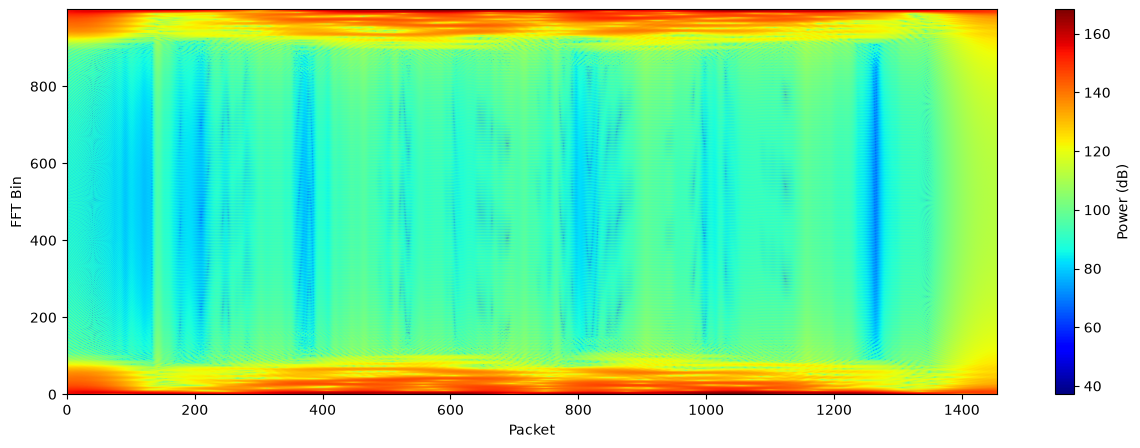

In [49]:
import matplotlib.pyplot as plt

# full unmasked spectrogram (dB) — sanity check before cropping
plt.figure(figsize=(15, 5))

plt.imshow(
    10 * np.log10(spec + 1e-12),
    aspect='auto',
    origin='lower',
    cmap='jet'
)

plt.xlabel("Packet")
plt.ylabel("FFT Bin")
plt.colorbar(label="Power (dB)")
plt.show()

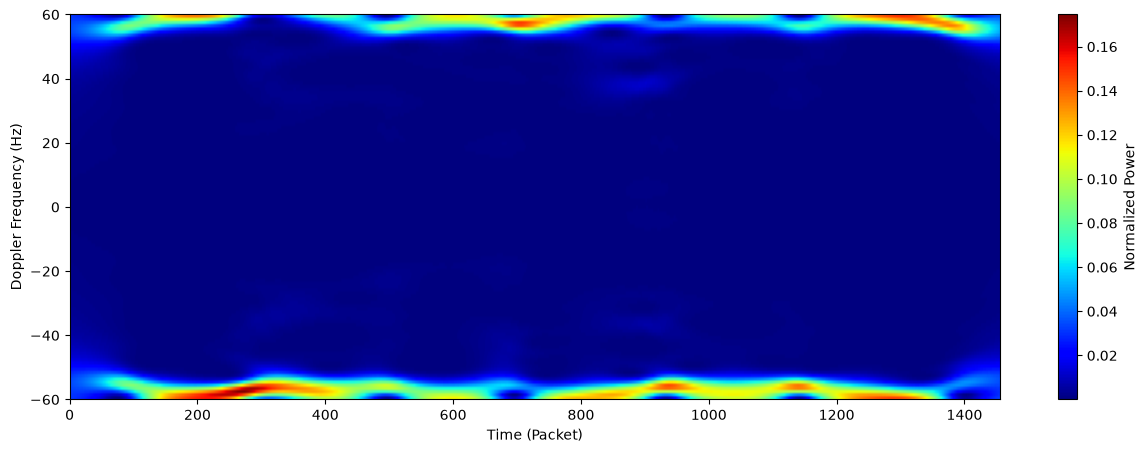

In [50]:
# final cropped + normalized Doppler spectrogram
plt.figure(figsize=(15, 5))

plt.imshow(
    freq_time_prof,
    aspect='auto',
    origin='lower',
    extent=[0, freq_time_prof.shape[1], -60, 60],
    cmap='jet'
)

plt.xlabel("Time (Packet)")
plt.ylabel("Doppler Frequency (Hz)")
plt.colorbar(label="Normalized Power")
plt.show()

## Stage 8 — toward BVP 
Widar3.0 combines multi-receiver Doppler spectra and solves an inverse problem for a 2D velocity grid.

In [53]:
import numpy as np

def dvm_loss(P_flat, VDM, D_target, lam):
    """20x20 velocity grid -> predicted Doppler spectra, EMD-style loss + L0 sparsity."""
    P = P_flat.reshape(20, 20)
    D_pred = np.einsum("ij,ijrf->rf", P, VDM)

    loss = 0.0
    for rx in range(D_target.shape[0]):
        if np.any(D_target[rx]):
            cum = np.cumsum(D_pred[rx] - D_target[rx])
            loss += np.sum(np.abs(cum))

    loss += lam * np.count_nonzero(P)
    return loss

In [54]:
import numpy as np
from scipy.optimize import minimize


def dvm_target_func(P_flat, VDM, doppler_target, lam=1e-7, norm_mode=0):
    """MATLAB DVM_target_func translation — objective for recovering velocity grid P."""
    M = VDM.shape[0]
    P = P_flat.reshape(M, M)

    # forward model: candidate P -> predicted per-receiver Doppler spectra
    doppler_pred = np.einsum("ij,ijrf->rf", P, VDM)

    loss = 0.0
    for rx in range(doppler_target.shape[0]):
        if np.any(doppler_target[rx]):
            diff = doppler_pred[rx] - doppler_target[rx]
            cumulative = np.cumsum(diff)  # 1D earth-mover-distance proxy
            loss += np.sum(np.abs(cumulative))

    if norm_mode == 1:
        loss += lam * np.sum(P)            # L1
    elif norm_mode == 0:
        loss += lam * np.count_nonzero(P)  # L0 (sparse velocity grid)

    return loss


def reconstruct_velocity(VDM, doppler_target, upper_bound, lam=1e-7, norm_mode=0):
    """Solve for P via SLSQP. NOTE: never called — VDM/doppler_target not built here."""
    M = VDM.shape[0]
    x0 = np.zeros(M * M)
    bounds = [(0.0, upper_bound) for _ in range(M * M)]

    result = minimize(
        fun=dvm_target_func,
        x0=x0,
        args=(VDM, doppler_target, lam, norm_mode),
        method="SLSQP",
        bounds=bounds,
        options={"maxiter": 1000, "disp": True}
    )

    return result.x.reshape(M, M)

In [55]:
import scipy.io as sio

# precomputed Widar3.0 BVP file, for comparison against our own pipeline
mat = sio.loadmat("/Users/umang.babu/Downloads/wifi/BVP/20181117-VS/6-link/user4/user4-1-1-1-1-1-1e-07-100-20-100000-L0.mat")

for k, v in mat.items():
    if not k.startswith("__"):
        print(f"{k:25s} {type(v)} {getattr(v, 'shape', None)}")

velocity_spectrum_ro      <class 'numpy.ndarray'> (20, 20, 14)


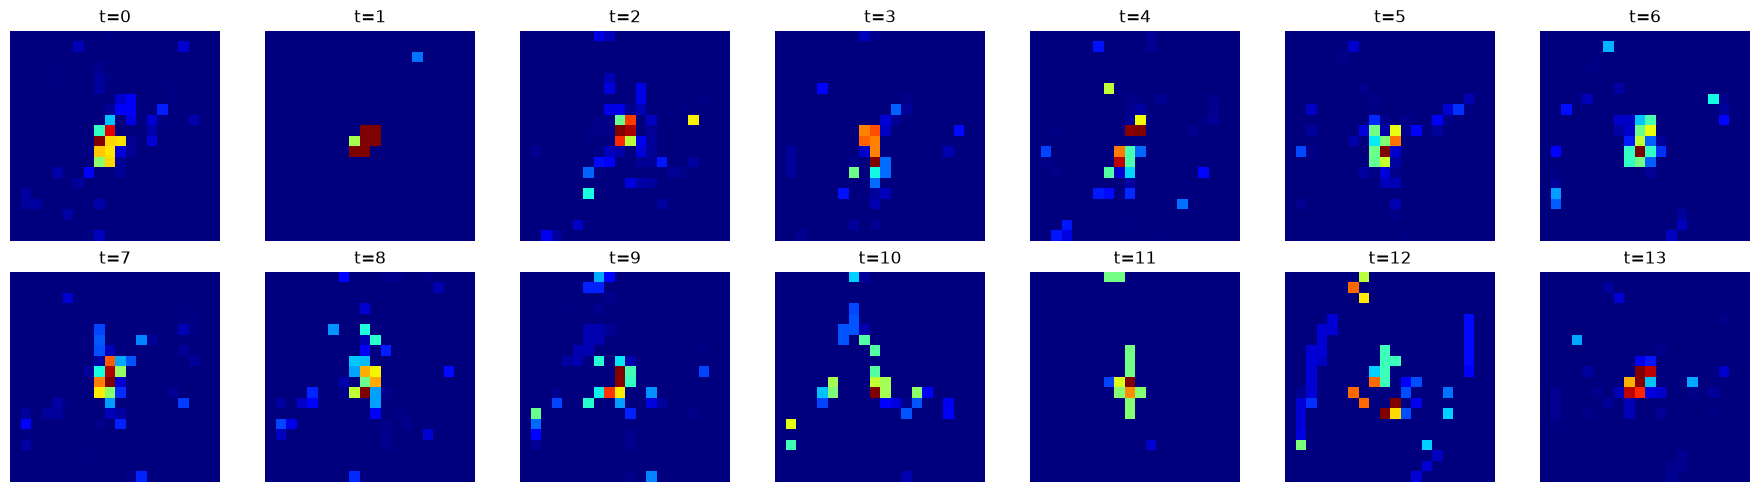

In [56]:
import scipy.io as sio
import matplotlib.pyplot as plt

mat = sio.loadmat("/Users/umang.babu/Downloads/wifi/BVP/20181117-VS/6-link/user4/user4-1-1-1-1-1-1e-07-100-20-100000-L0.mat")
velocity = mat["velocity_spectrum_ro"]  # (20, 20, T) precomputed BVP

# preview a few time frames of the velocity grid
rows, cols = 2, 7
fig, axes = plt.subplots(rows, cols, figsize=(18, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(velocity[:, :, i], origin="lower", cmap="jet", interpolation="nearest")
    ax.set_title(f"t={i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

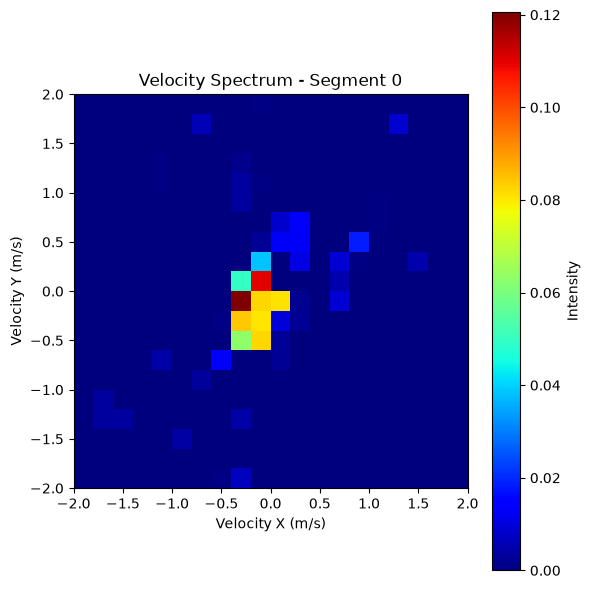

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

mat = sio.loadmat("/Users/umang.babu/Downloads/wifi/BVP/20181117-VS/6-link/user4/user4-1-1-1-1-1-1e-07-100-20-100000-L0.mat")
velocity = mat["velocity_spectrum_ro"]

velocity_bin = np.linspace(-2, 2, 20)

segment = 0

plt.figure(figsize=(6,6))

plt.imshow(
    velocity[:, :, segment],
    origin="lower",
    extent=[
        velocity_bin[0],
        velocity_bin[-1],
        velocity_bin[0],
        velocity_bin[-1]
    ],
    cmap="jet",
    aspect="equal"
)

plt.colorbar(label="Intensity")

plt.xlabel("Velocity X (m/s)")
plt.ylabel("Velocity Y (m/s)")

plt.title(f"Velocity Spectrum - Segment {segment}")

plt.tight_layout()
plt.show()

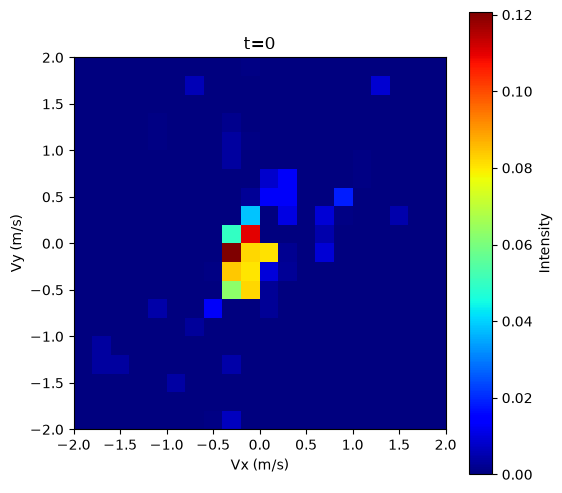

In [ ]:
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

mat = sio.loadmat("/Users/umang.babu/Downloads/wifi/BVP/20181117-VS/6-link/user4/user4-1-1-1-1-1-1e-07-100-20-100000-L0.mat")
# user4 — user id
# 1 — gesture type 1: Push&Pull
# 1 — torso location(1.365, 0.455)
# 1 — face orientation (-90)
# 1 — repetition
velocity = mat["velocity_spectrum_ro"]

# animate BVP over time
fig, ax = plt.subplots(figsize=(6, 6))
velocity_bin = np.linspace(-2, 2, 20)

im = ax.imshow(
    velocity[:, :, 0],
    cmap="jet",
    origin="lower",
    extent=[velocity_bin[0], velocity_bin[-1], velocity_bin[0], velocity_bin[-1]]
)
ax.set_xlabel("Vx (m/s)")
ax.set_ylabel("Vy (m/s)")
plt.colorbar(im, ax=ax, label="Intensity")

def update(i):
    im.set_data(velocity[:, :, i])
    ax.set_title(f"t={i}")
    return [im]

anim = FuncAnimation(fig, update, frames=velocity.shape[2], interval=150)
HTML(anim.to_jshtml())